In [1]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()

importer.insert_path("peregrin\\src")
importer.insert_path("peregrin\\data")
importer.insert_path("peregrin")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib to sys.path


In [2]:
from peregrin.data import b_cells
b_cells

C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\data_handler\df_metadata_manager.py:176: InputWarning: Inconsistent number of frames across input files -> found {59, 60}.
  self._check()


track_id,time_point,x_coordinate,y_coordinate,set,subset,group
f64,f64,f64,f64,str,str,str
0.0,240.0,1072.441598,693.055117,"""b_memory""","""ctr""","""memory_ctr_BC39.csv"""
0.0,1320.0,1093.351399,676.847641,"""b_memory""","""ctr""","""memory_ctr_BC39.csv"""
0.0,420.0,1104.689939,683.918605,"""b_memory""","""ctr""","""memory_ctr_BC39.csv"""
0.0,360.0,1093.743013,686.18834,"""b_memory""","""ctr""","""memory_ctr_BC39.csv"""
0.0,1020.0,1100.831004,674.251173,"""b_memory""","""ctr""","""memory_ctr_BC39.csv"""
…,…,…,…,…,…,…
208.0,3480.0,962.117142,386.679842,"""b_naive""","""mu""","""naive_mu_BC43.csv"""
209.0,2820.0,544.647798,303.863392,"""b_naive""","""mu""","""naive_mu_BC43.csv"""
209.0,2880.0,544.623976,303.76054,"""b_naive""","""mu""","""naive_mu_BC43.csv"""


In [3]:
data = b_cells

In [4]:
import peregrin.src.data_handler.data_loader as load_module
import peregrin.src.data_handler.directory_reader as reader_module
reload(load_module)
reload(reader_module)
load_data = load_module.load_data
make_tree = reader_module.make_tree

In [5]:
# data = load_data(r"./dummy_data/testing_0")

# data = load_data(
#     r"./dummy_data/tree",
#     colnames = {
#         'id': 'track_id',
#         't': 'time_point',
#         'x': 'x_coordinate',
#         'y': 'y_coordinate'
#     },
# )

# data = load_data(
#     r"C:\Users\modri\Desktop\Repositories\peregrin\cell-tracking-data\01\b_naive\ctr\naive_ctr_BC42.csv"
# )

In [6]:
# tree = make_tree(r"C:\Users\modri\Desktop\Repositories\peregrin\cell-tracking-data")

# data = load_data(tree.get())

In [7]:
data.metadata.write(spatialunits='um', timeunits='s')
data.metadata.get()

{'timeunits': 's',
 'spatialunits': 'μm',
 'nframes': '',
 'timeinterval': 60.0,
 'columns': ['LABEL',
  'ID',
  'TRACK_ID',
  'QUALITY',
  'POSITION_X',
  'POSITION_Y',
  'POSITION_Z',
  'POSITION_T',
  'FRAME',
  'RADIUS',
  'VISIBILITY',
  'MANUAL_SPOT_COLOR',
  'MEAN_INTENSITY_CH1',
  'MEDIAN_INTENSITY_CH1',
  'MIN_INTENSITY_CH1',
  'MAX_INTENSITY_CH1',
  'TOTAL_INTENSITY_CH1',
  'STD_INTENSITY_CH1',
  'CONTRAST_CH1',
  'SNR_CH1']}

In [8]:
import peregrin.src.object_interface as object_module
reload(object_module)
create_object = object_module.create_object

data_object = create_object(data)

In [9]:
data_object.compute_tracks()

group,subset,set,track_uid,speed_min,speed_max,speed_mean,speed_sd,speed_median,track_length,x_location,y_location,max_distance_reached,track_start_frame,track_end_frame,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_points,track_displacement,straightness_ratio,track_id
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""memory_ctr_BC39.csv""","""ctr""","""b_memory""",0,0.020141,0.229515,0.106979,0.071081,0.095415,192.562995,1094.830067,681.355184,46.094352,0,30,0.012241,0.118236,2.255481,0.871357,80.382617,0.043216,31,22.767964,0.118236,0.0
"""memory_ctr_BC39.csv""","""ctr""","""b_memory""",1,0.143331,0.267316,0.184903,0.034672,0.180029,122.036003,76.369174,698.405614,93.985338,0,11,0.130535,0.705966,0.394393,0.237321,24.247918,0.033678,12,93.985338,0.770144,1.0
"""memory_ctr_BC39.csv""","""ctr""","""b_memory""",2,0.047809,0.237677,0.13547,0.052644,0.139528,162.563682,791.613574,693.86715,33.321433,0,20,0.019803,0.153487,1.276848,0.793589,64.584291,0.051257,21,24.951444,0.153487,2.0
"""memory_ctr_BC39.csv""","""ctr""","""b_memory""",3,0.043922,0.198376,0.115091,0.0467,0.114572,131.203777,1128.342607,691.630295,44.529236,0,19,0.037108,0.32242,-0.042556,0.584931,45.691377,0.038076,20,44.529236,0.33939,3.0
"""memory_ctr_BC39.csv""","""ctr""","""b_memory""",4,0.085788,0.25359,0.159677,0.044352,0.152967,114.967656,1023.997629,685.661742,14.492307,0,12,0.017303,0.108365,-2.161114,0.915094,116.581543,0.149464,13,13.496688,0.117396,4.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""naive_mu_BC43.csv""","""mu""","""b_naive""",8721,0.006316,0.006316,0.006316,null,0.006316,0.378982,1122.657626,100.104,0.378982,0,1,0.003158,0.5,-2.436283,0.0,null,null,2,0.378982,1.0,206.0
"""naive_mu_BC43.csv""","""mu""","""b_naive""",8722,0.020625,0.020625,0.020625,null,0.020625,1.237509,886.963225,653.379917,1.237509,0,1,0.010313,0.5,0.325209,0.0,null,null,2,1.237509,1.0,207.0
"""naive_mu_BC43.csv""","""mu""","""b_naive""",8723,0.007996,0.007996,0.007996,null,0.007996,0.479739,962.232075,386.890384,0.479739,0,1,0.003998,0.5,-2.070479,0.0,null,null,2,0.479739,1.0,208.0


C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\graphs\painter.py:177: UserWarning: More categories (18) than colors (6). Randomly generating additional colors.
  warn(f"More categories ({len(categories)}) than colors ({len(palette)}). "


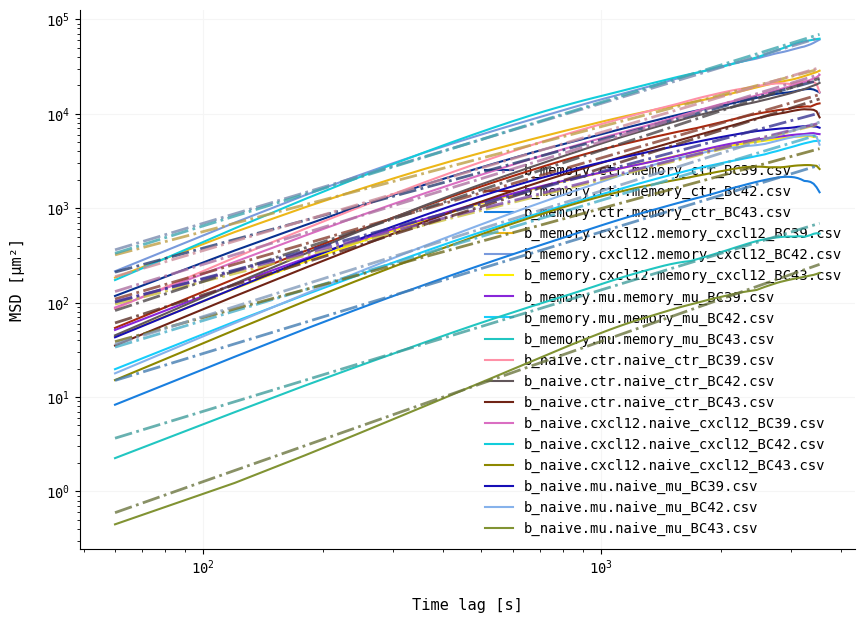

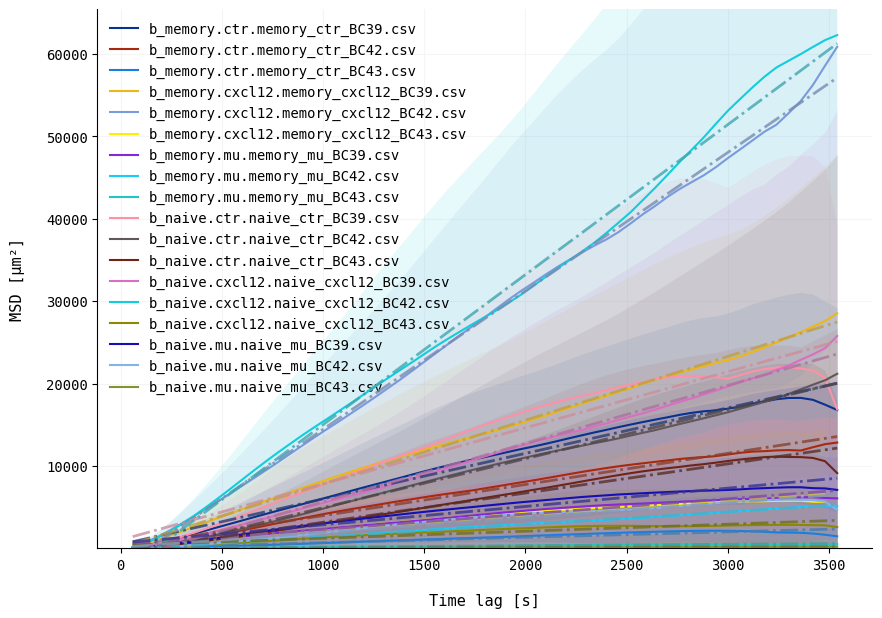

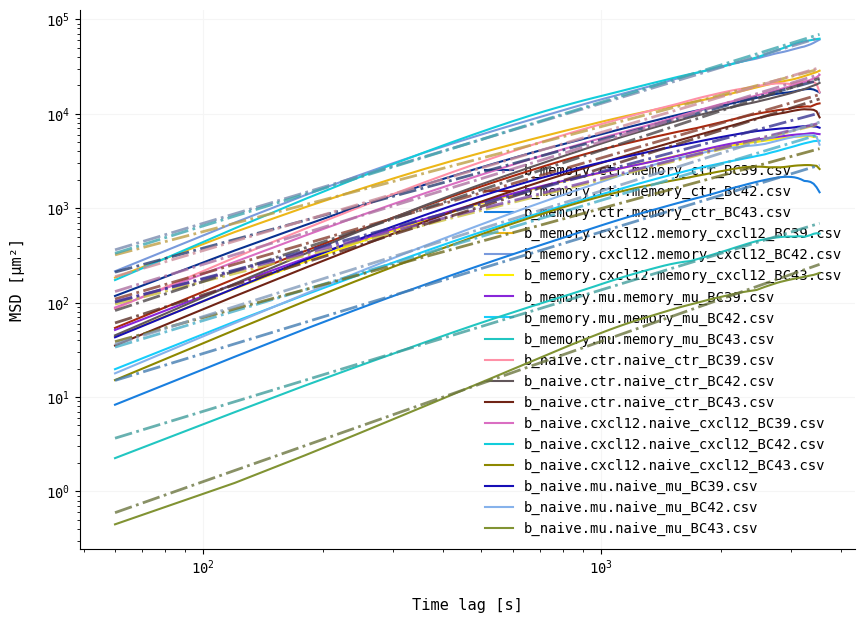

In [10]:
data_object.plot_msd(grid = True, linear_fit = True, band = 'sd', grouping_level='group')
data_object.plot_msd(grid = True, linear_fit = True, log = True, grouping_level='group')

In [11]:
list_ = [1, 2, 3]

list_ += [4]
print(list_)

[1, 2, 3, 4]


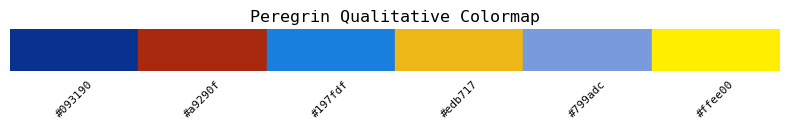

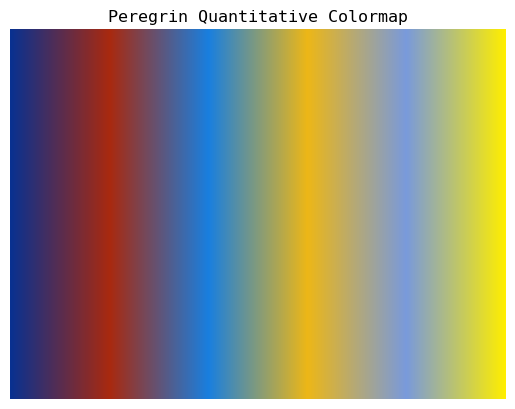

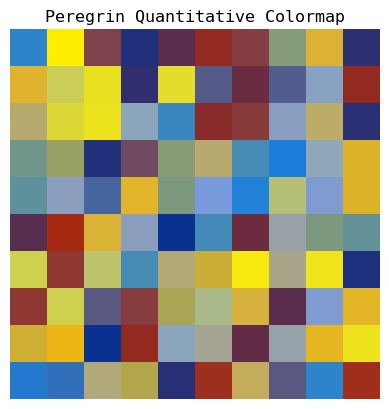

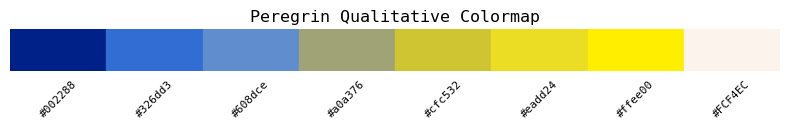

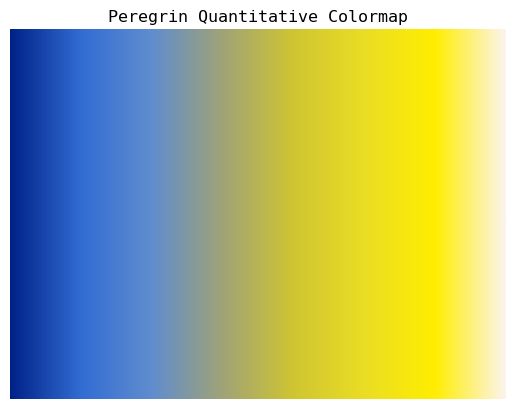

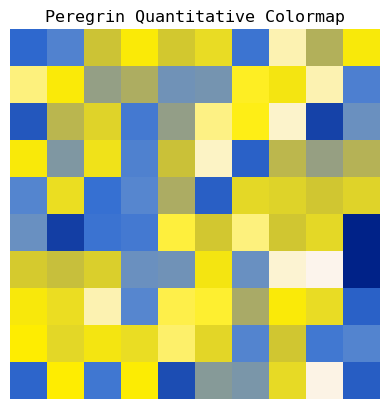

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

peregrin_cmap2 = ['#002288', "#326dd3", '#608dce', '#a0a376', '#cfc532', '#eadd24', '#ffee00', "#FCF4EC"]
peregrin_cmap1 = ['#093190', "#a9290f", '#197fdf', '#edb717', '#799adc',  '#ffee00']

def peregrin_cmap_func(peregrin_cmap):

    fig, ax = plt.subplots(figsize=(8, 1.5))
    n = len(peregrin_cmap)
    for i, color in enumerate(peregrin_cmap):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, -0.15, color, ha='center', va='top', fontsize=8, rotation=45)

    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title("Peregrin Qualitative Colormap")
    plt.tight_layout()
    plt.show()

    quantitative_cmap = mcolors.LinearSegmentedColormap.from_list("_peregrin", peregrin_cmap)
    plt.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()

    plt.imshow(np.array(np.repeat(np.random.rand(10, 10), 1, axis=0)), cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()


for cmap in [peregrin_cmap1, peregrin_cmap2]:
    peregrin_cmap_func(cmap)